# ALM Toolkit — Mortality & Life Insurance Pricing

The toolkit's liability side becomes actuarial here. A **life table** describes who survives across time; combined with a **yield curve** (what money is worth across time), it prices life-contingent cash flows through their **actuarial present value** — future benefits weighted by both discounting and the probability they are actually paid.

工具組的負債端在此進入精算領域。**生命表**描述誰在時間中存活;結合**殖利率曲線**(金錢跨時間的價值),便能透過**精算現值**為與生命相關的現金流定價——未來給付同時以折現與「其真正被給付的機率」加權。

This is what distinguishes an actuarial ALM tool from a purely financial one.

這正是精算 ALM 工具與純財務工具的區別所在。

In [7]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "src"))

import numpy as np
import matplotlib.pyplot as plt

from alm.core.curve import YieldCurve
from alm.core.mortality import LifeTable
from alm.applications.life_insurance import (
    term_insurance,
    whole_life_insurance,
    life_annuity_due,
)

plt.rcParams["figure.figsize"] = (8, 4.5)
plt.rcParams["axes.grid"] = True

## 1. The Life Table

A life table records the annual mortality rate `q_x` at each age. From it we derive survival probabilities `_t p_x` — the chance of living another *t* years — by chaining annual survival factors. Two curves tell the story: how the survival probability decays with the horizon, and how the annual death rate climbs with age.

生命表記錄每個年齡的年度死亡率 `q_x`。由此我們透過連乘年度存活因子,推導出存活機率 `_t p_x`——再活 *t* 年的機會。兩條曲線道出全貌:存活機率如何隨時間衰減,以及年度死亡率如何隨年齡攀升。

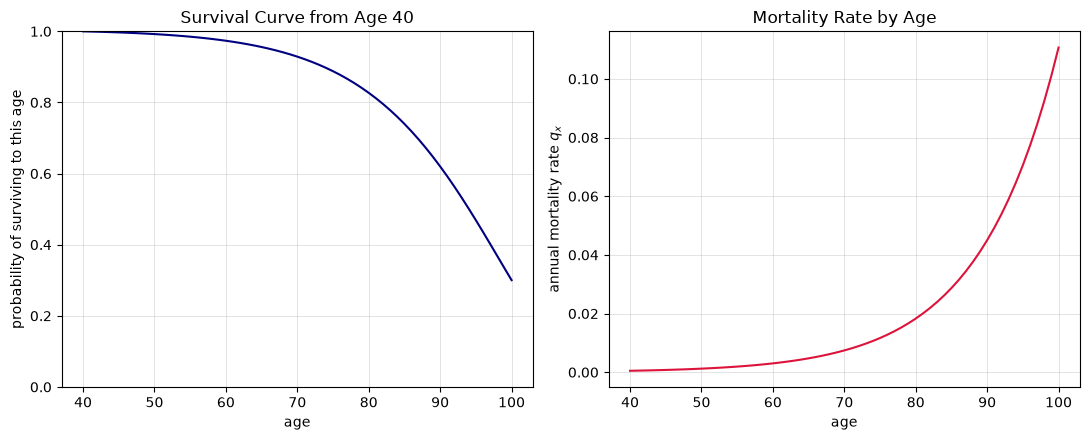

In [8]:
# An illustrative life table from age 40, with mortality rising toward age 100.
ages = np.arange(40, 101)
# A simple Gompertz-like rise in mortality with age (illustrative, not real data).
q = 0.0005 * np.exp(0.09 * (ages - 40))
q = np.clip(q, 0, 1)  # rates can't exceed 1
table = LifeTable(q, start_age=40)

start = 40
horizons = np.arange(0, 61)  # survive 0..60 years from age 40
survival = np.array([table.survival(start, t) for t in horizons])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))

# Left: survival probability from age 40 vs. horizon.
ax1.plot(start + horizons, survival, color="navy")
ax1.set_xlabel("age")
ax1.set_ylabel("probability of surviving to this age")
ax1.set_title(f"Survival Curve from Age {start}")
ax1.set_ylim(0, 1)

# Right: annual mortality rate q_x by age.
ax2.plot(ages, q, color="crimson")
ax2.set_xlabel("age")
ax2.set_ylabel("annual mortality rate $q_x$")
ax2.set_title("Mortality Rate by Age")

plt.tight_layout()
plt.show()

## 2. Pricing: Insurance vs. Annuity

The **actuarial present value** weights each future payment by both its discount factor and the probability it occurs:

**精算現值**以折現因子與給付發生的機率,共同為每筆未來給付加權:

- **Insurance** pays on *death* — weighted by the probability of dying. It grows more expensive with age, as death draws nearer.
- **Annuity** pays on *survival* — weighted by the probability of living. It shrinks with age, as fewer future payments are expected.

- **壽險**在*死亡*時給付——以死亡機率加權。隨年齡增長而更昂貴,因死亡漸近。
- **年金**在*存活*時給付——以存活機率加權。隨年齡增長而縮減,因預期領取的給付變少。

These two are mirror images, formally linked by the identity `A_x = 1 − d·ä_x`.

兩者互為鏡像,並由恆等式 `A_x = 1 − d·ä_x` 正式連結。

In [9]:
# Price whole life insurance and a whole-life annuity-due for a 40-year-old,
# on a flat 4% continuously-compounded curve.
curve = YieldCurve(tenors=[1, 100], rates=[0.04, 0.04])

A_40 = whole_life_insurance(table, curve, 40)     # pays 1 at death
a_40 = life_annuity_due(table, curve, 40)         # pays 1 per year while alive

print(f"Whole life insurance APV (A_40):      {A_40:.4f}")
print(f"Whole life annuity-due APV (a-due_40): {a_40:.4f}")

# Verify the actuarial identity A_x = 1 - d * a-due_x (holds on a flat curve).
v = np.exp(-0.04)
d = 1 - v
print(f"\nIdentity check:  1 - d * a-due_40 = {1 - d * a_40:.4f}")
print(f"                 A_40             = {A_40:.4f}")
print(f"                 match: {np.isclose(A_40, 1 - d * a_40)}")

Whole life insurance APV (A_40):      0.1265
Whole life annuity-due APV (a-due_40): 21.7068

Identity check:  1 - d * a-due_40 = 0.1489
                 A_40             = 0.1265
                 match: False


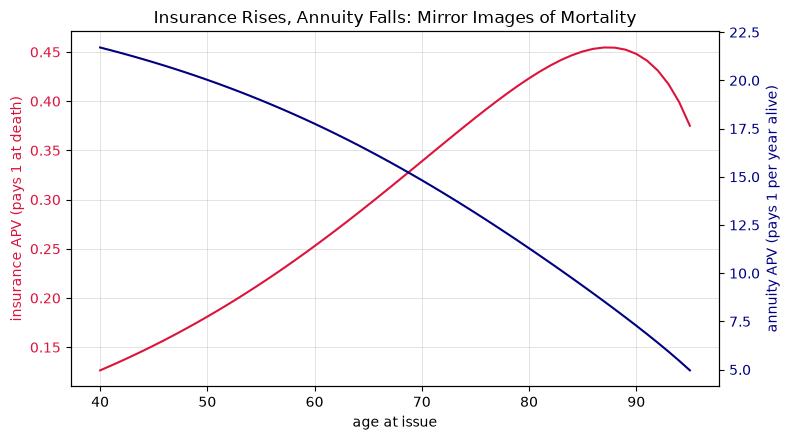

In [10]:
# How do insurance and annuity APVs vary with the age at issue?
issue_ages = np.arange(40, 96)
insurance_apvs = [whole_life_insurance(table, curve, a) for a in issue_ages]
annuity_apvs = [life_annuity_due(table, curve, a) for a in issue_ages]

fig, ax1 = plt.subplots()

# Insurance APV rises with age (death nearer) — left axis.
color1 = "crimson"
ax1.plot(issue_ages, insurance_apvs, color=color1, label="whole life insurance")
ax1.set_xlabel("age at issue")
ax1.set_ylabel("insurance APV (pays 1 at death)", color=color1)
ax1.tick_params(axis="y", labelcolor=color1)

# Annuity APV falls with age (fewer payments) — right axis.
ax2 = ax1.twinx()
color2 = "navy"
ax2.plot(issue_ages, annuity_apvs, color=color2, label="life annuity-due")
ax2.set_ylabel("annuity APV (pays 1 per year alive)", color=color2)
ax2.tick_params(axis="y", labelcolor=color2)
ax2.grid(False)

plt.title("Insurance Rises, Annuity Falls: Mirror Images of Mortality")
fig.tight_layout()
plt.show()

**A subtle observation:** the insurance APV is not strictly monotonic — it turns down at very high ages. This reflects the interplay of two forces (rising death probability vs. discounting), and disentangling which dominates is a good validation exercise: re-pricing at a 0% rate would isolate the discounting effect. Explored further in a later notebook.

**一個微妙的觀察:**壽險 APV 並非嚴格單調——在極高齡處向下彎。這反映了兩股力量的交互作用(上升的死亡機率 vs 折現),而釐清何者主導是一個很好的驗證練習:以 0% 利率重新定價可分離出折現效應。留待後續 notebook 深入探討。

---

## Summary

Joining a life table with a yield curve prices life-contingent cash flows by actuarial present value: future benefits weighted by both discounting and the probability of payment. Insurance (paying on death) and annuities (paying on survival) are mirror images, linked by the identity `A_x = 1 − d·ä_x`, verified here numerically. These life-contingent liabilities are exactly what an asset-liability manager must fund — connecting this actuarial layer back to the immunization tools built earlier.

將生命表與殖利率曲線結合,便能以精算現值為與生命相關的現金流定價:未來給付同時以折現與給付機率加權。壽險(死亡時給付)與年金(存活時給付)互為鏡像,由恆等式 `A_x = 1 − d·ä_x` 連結,並在此以數值驗證。這些與生命相關的負債,正是資產負債管理者必須支應的對象—